In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Books_Data_Clean.csv")

# Clean up column names by stripping whitespace
df.columns = df.columns.str.strip()

In [42]:
df.nunique()

index                  1070
Publishing Year         150
Book Name              1045
Author                  735
language_code             8
Author_Rating             4
Book_average_rating     134
Book_ratings_count     1064
genre                     4
gross sales             831
publisher revenue       610
sale price              149
sales rank              865
Publisher                 9
units sold              491
dtype: int64

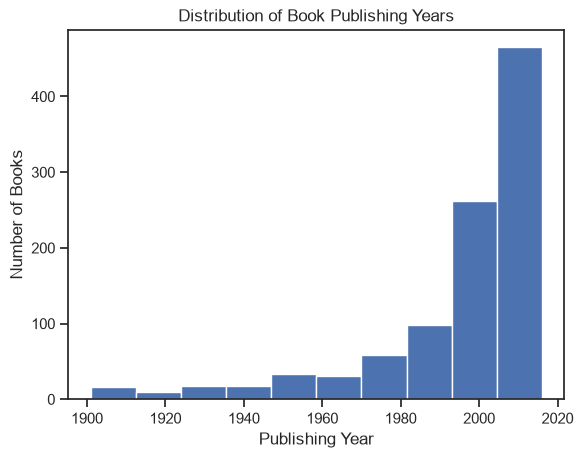

In [43]:
df = df[df["Publishing Year"]> 1900]

# Set style
sns.set_theme(style='ticks')

# Creating a histogram of the publishing year
plt.hist(df['Publishing Year'])
plt.title('Distribution of Book Publishing Years')
plt.xlabel('Publishing Year')
plt.ylabel('Number of Books')
plt.show()

In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1009 non-null   int64  
 1   Publishing Year      1009 non-null   float64
 2   Book Name            988 non-null    str    
 3   Author               1009 non-null   str    
 4   language_code        960 non-null    str    
 5   Author_Rating        1009 non-null   str    
 6   Book_average_rating  1009 non-null   float64
 7   Book_ratings_count   1009 non-null   int64  
 8   genre                1009 non-null   str    
 9   gross sales          1009 non-null   float64
 10  publisher revenue    1009 non-null   float64
 11  sale price           1009 non-null   float64
 12  sales rank           1009 non-null   int64  
 13  Publisher            1009 non-null   str    
 14  units sold           1009 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 126.1 KB

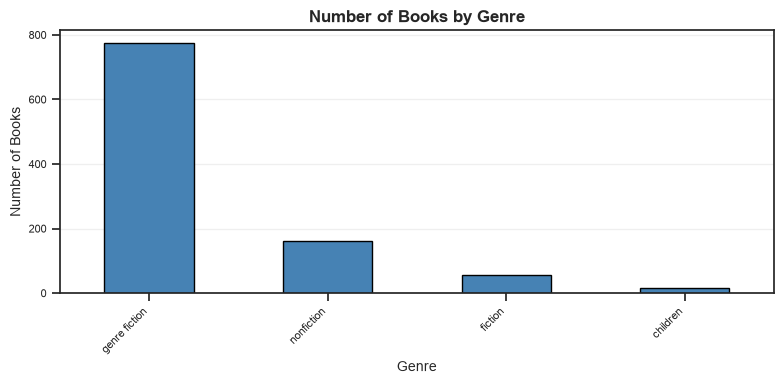

In [45]:
# Bar chart showing different genres
# Using basic enhancement with labels and title
df["genre"].value_counts().plot(kind="bar", figsize=(8, 4), color='steelblue', edgecolor='black')
plt.title('Number of Books by Genre', fontsize=12, fontweight='bold')
plt.xlabel('Genre', fontsize=10)
plt.ylabel('Number of Books', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [46]:
# Group by the author and calculate the average rating for each author
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 680, dtype: float64

Average rating per genre:
genre
children         4.03
fiction          4.04
genre fiction    4.01
nonfiction       4.02
Name: Book_average_rating, dtype: float64


C:\Users\Greg\AppData\Local\Temp\ipykernel_13356\2302256643.py:16: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=df, x='genre', y='Book_average_rating',


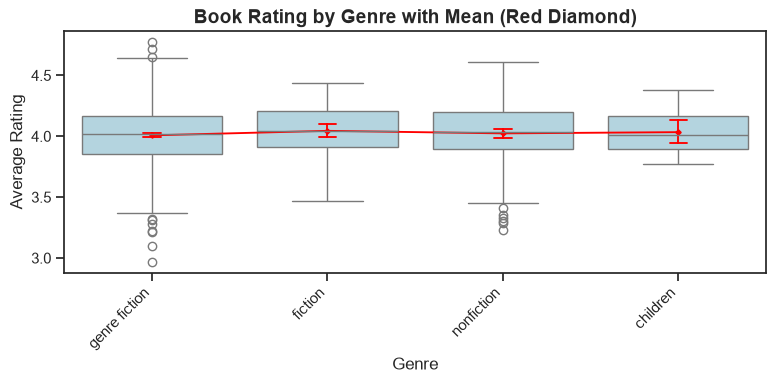

In [47]:
#Basic boxplot for genre ratings

# To take note in the figure, we can calculate the average rating per genre
genre_avg = df.groupby('genre')['Book_average_rating'].mean().round(2)
print("Average rating per genre:")
print(genre_avg)

# Set style
sns.set_theme(style='ticks')

# Boxplot with mean shown as a point
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='genre', y='Book_average_rating', color='lightblue')

# Add mean as a red diamond
sns.pointplot(data=df, x='genre', y='Book_average_rating', 
              estimator='mean', color='red', markers='D', capsize=0.1, scale=0.5)

plt.title('Book Rating by Genre with Mean (Red Diamond)', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

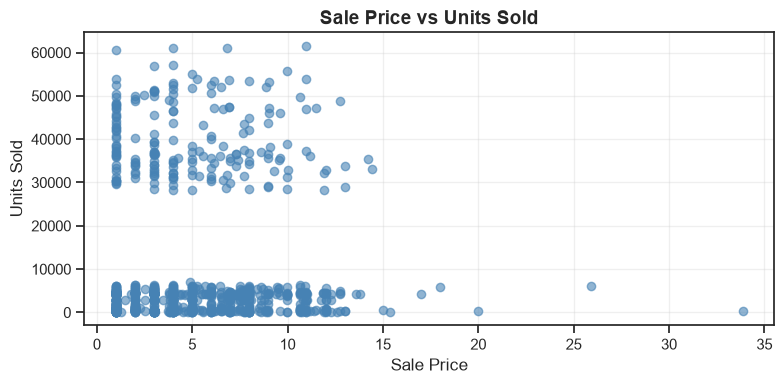

In [48]:
# Set style
sns.set_theme(style='ticks')

# Create scatter plot
plt.figure(figsize=(8, 4))
plt.scatter(df['sale price'], df['units sold'], alpha=0.6, color='steelblue')
plt.title('Sale Price vs Units Sold', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

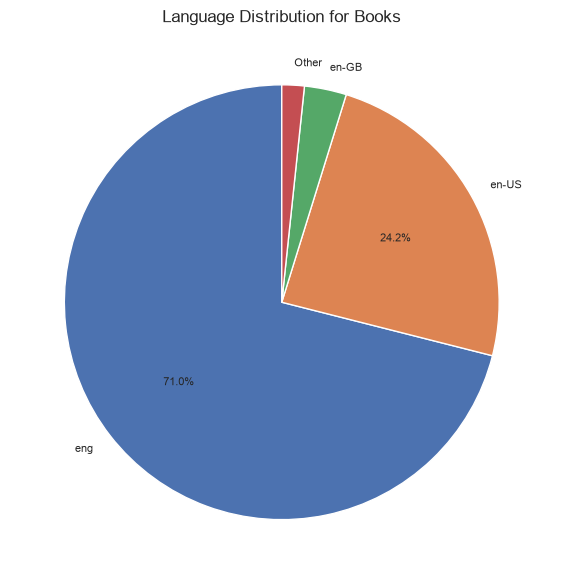


'Other' languages breakdown:
language_code
en-CA    7
fre      4
spa      2
ara      2
nl       1
Name: count, dtype: int64


In [49]:
#Pie chart showing the percentages of the languages used in the books

# Get language counts
language_counts = df["language_code"].value_counts()

# Define top 3 and others
top_3 = language_counts.head(3)
others = language_counts.iloc[3:]

# Create labels for pie chart
# Top 3 show their names, others grouped as 'Other'
labels = list(top_3.index) + ['Other']

# Create values
values = list(top_3.values) + [others.sum()]

# Custom autopct: show percentage only for slices > threshold
def custom_autopct(pct):
    # Only show percentage if slice is > 5% (or adjust threshold)
    return f'{pct:.1f}%' if pct > 5 else ''

# Create pie chart
plt.figure(figsize=(10, 6))
plt.pie(values, 
        labels=labels,
        autopct=custom_autopct,
        startangle=90,
        textprops={'fontsize': 8})
plt.title('Language Distribution for Books')
plt.tight_layout()
plt.show()

# Print breakdown of 'Other' categories
print("\n'Other' languages breakdown:")
print(others)

In [52]:
# Group by publisher and sum the revenue
df.groupby("Publisher")["publisher revenue"].sum().sort_values(ascending=False)

Publisher
Penguin Group (USA) LLC                 202987.308
Random House LLC                        185744.244
Amazon Digital Services,  Inc.          144415.350
HarperCollins Publishers                124264.770
Hachette Book Group                     108446.700
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [55]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending=False)

Author_Rating
Intermediate    101710.152921
Famous           97306.470588
Novice           87318.464286
Excellent        83529.591954
Name: Book_ratings_count, dtype: float64

C:\Users\Greg\AppData\Local\Temp\ipykernel_13356\2600663903.py:23: UserWarning: Glyph 141 (\x8d) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Greg\AppData\Local\Temp\ipykernel_13356\2600663903.py:23: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Greg\AppData\Local\Temp\ipykernel_13356\2600663903.py:23: UserWarning: Glyph 144 (\x90) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Greg\AppData\Local\Temp\ipykernel_13356\2600663903.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


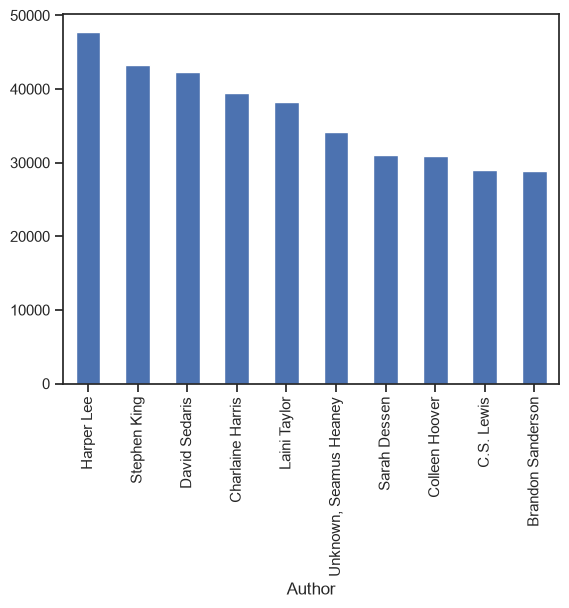

c:\Users\Greg\anaconda3\envs\book_sales\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Greg\anaconda3\envs\book_sales\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Greg\anaconda3\envs\book_sales\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 144 (\x90) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


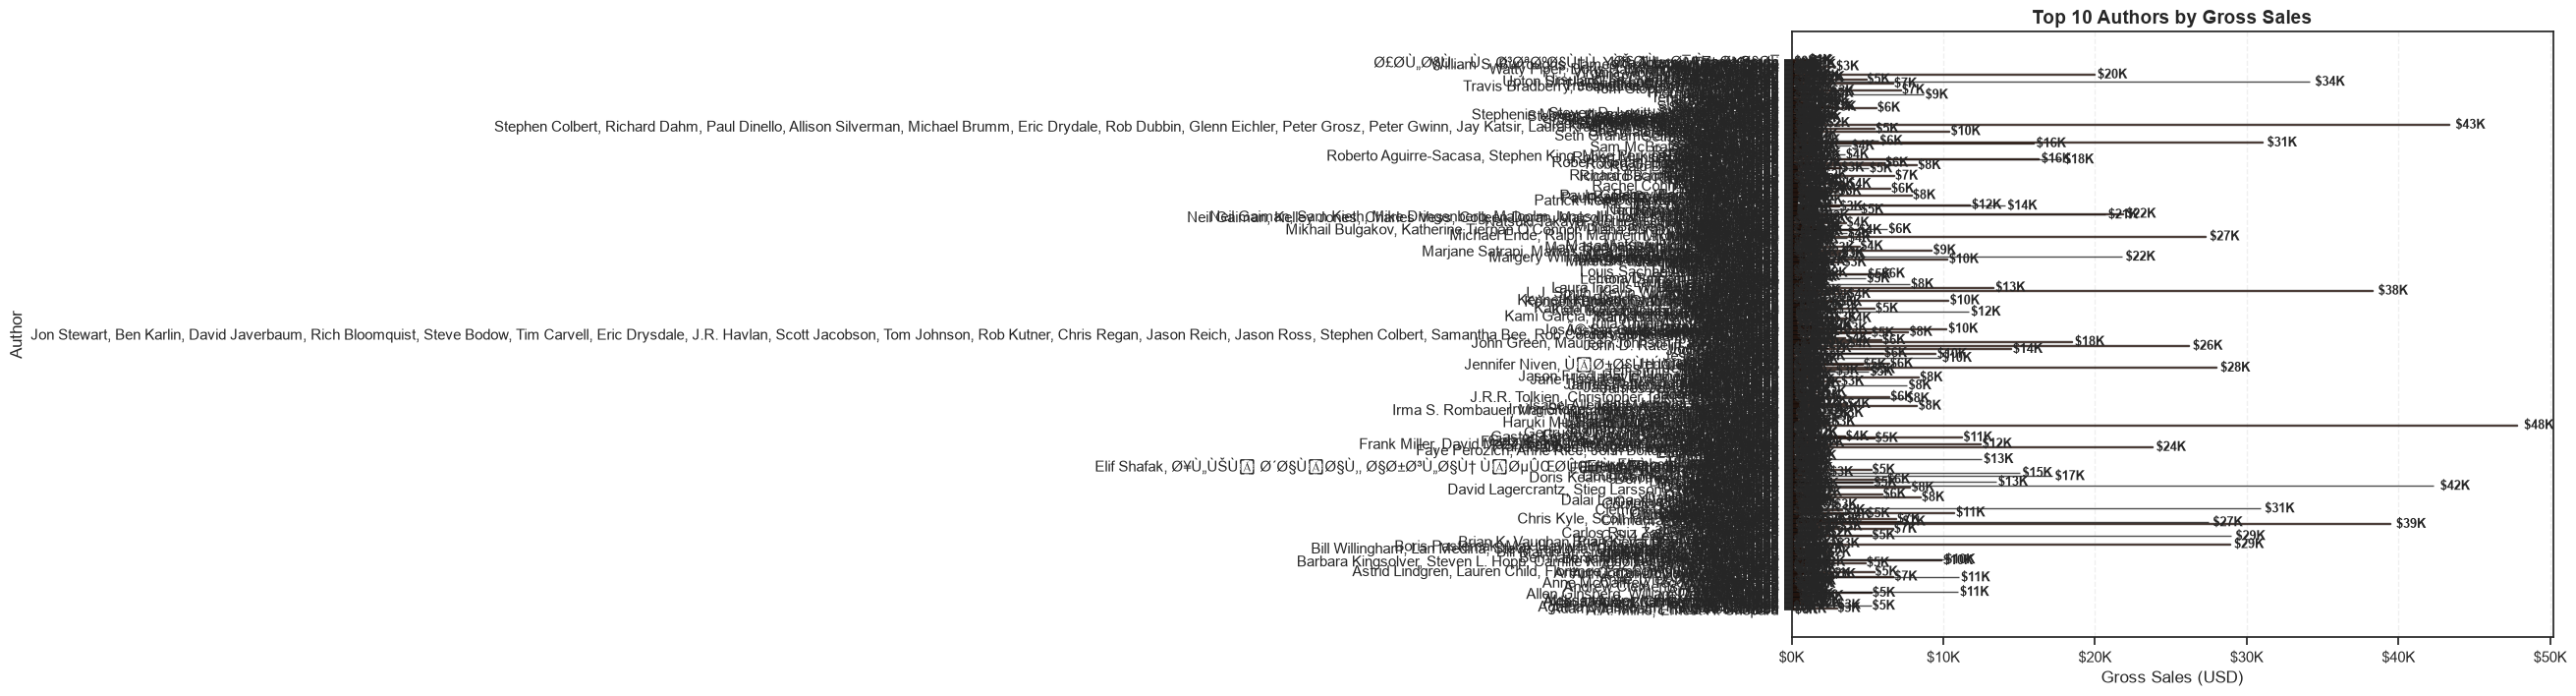

Top 10 Authors by Gross Sales:
Author
A.A. Milne, Ernest H. Shepard                        $214.92
A.S.A. Harrison                                      $784.16
Abbi Glines                                        $2,990.16
Adam Johnson                                         $108.90
Adam Mansbach, Ricardo CortÃ©s                       $113.85
                                                     ...    
William Styron                                       $220.89
Yana Toboso, Tomo Kimura                           $1,366.86
Zadie Smith                                          $167.31
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    $1,200.10
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  $1,128.87
Name: gross sales, Length: 680, dtype: str


In [62]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()
total_gross_sales_by_author.sort_values(ascending=False).head(10).plot(kind="bar")

# Plot horizontal
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(total_gross_sales_by_author.index, total_gross_sales_by_author.values,
               color='coral', edgecolor='black', alpha=0.7)

# Styling
ax.set_title('Top 10 Authors by Gross Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Gross Sales (USD)', fontsize=12)
ax.set_ylabel('Author', fontsize=12)
ax.grid(True, alpha=0.3, axis='x', linestyle='--')

# Currency format
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Add value labels
for bar, sales in zip(bars, total_gross_sales_by_author.values):
    ax.text(bar.get_width() + (sales * 0.01), bar.get_y() + bar.get_height()/2,
            f'${sales/1000:.0f}K', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Top 10 Authors by Gross Sales:")
print(total_gross_sales_by_author.apply(lambda x: f'${x:,.2f}'))

In [63]:
# Add summary statistics
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum().sort_values(ascending=False).head(10)

# Calculate stats
total_sales = total_gross_sales_by_author.sum()
avg_sales = total_gross_sales_by_author.mean()
top_author = total_gross_sales_by_author.index[0]
top_sales = total_gross_sales_by_author.values[0]

print(f"Total gross sales (top 10): ${total_sales:,.2f}")
print(f"Average gross sales (top 10): ${avg_sales:,.2f}")
print(f"Top author: {top_author} with ${top_sales:,.2f}")

Total gross sales (top 10): $365,099.49
Average gross sales (top 10): $36,509.95
Top author: Harper Lee with $47,795.00


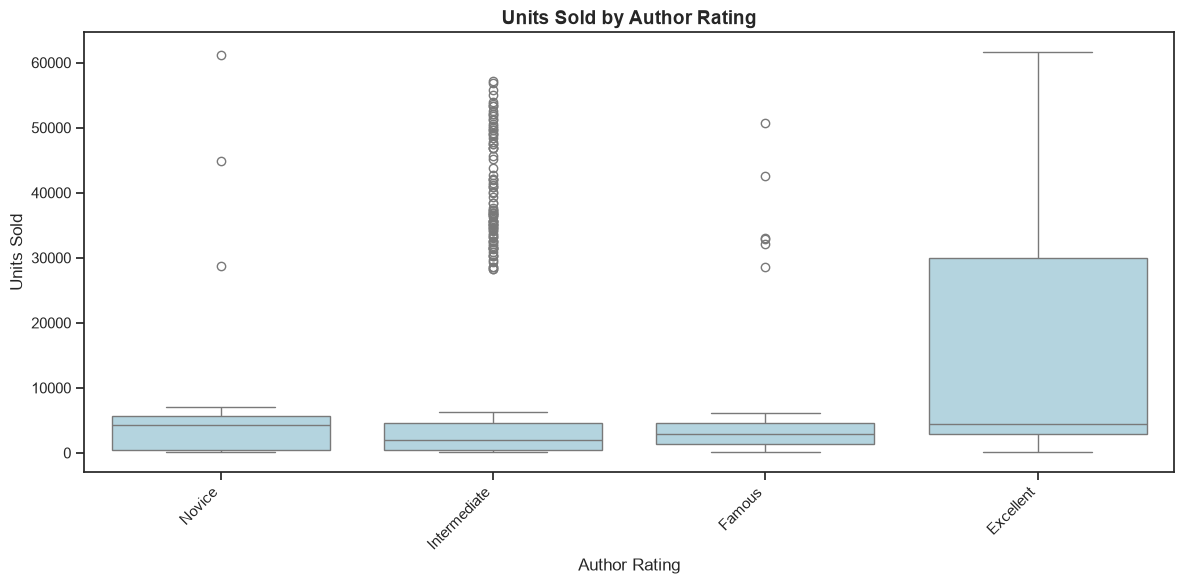

Units Sold Statistics by Author Rating:
               count          mean           std    min     25%     50%  \
Author_Rating                                                             
Excellent      348.0  13046.997126  16789.307380  106.0  2889.0  4400.0   
Famous          51.0   6756.705882  11460.468809  107.0  1361.0  2916.0   
Intermediate   582.0   8136.680412  14484.066924  106.0   476.0  1984.0   
Novice          28.0   7560.285714  14079.916932  107.0   469.5  4313.5   

                   75%      max  
Author_Rating                    
Excellent      29970.0  61560.0  
Famous          4576.5  50760.0  
Intermediate    4536.0  57240.0  
Novice          5629.5  61128.0  


In [64]:
# Boxplot with statistical summary
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Author_Rating', y='units sold', color='lightblue')

plt.title('Units Sold by Author Rating', fontsize=14, fontweight='bold')
plt.xlabel('Author Rating', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print statistics
print("Units Sold Statistics by Author Rating:")
print(df.groupby('Author_Rating')['units sold'].describe())

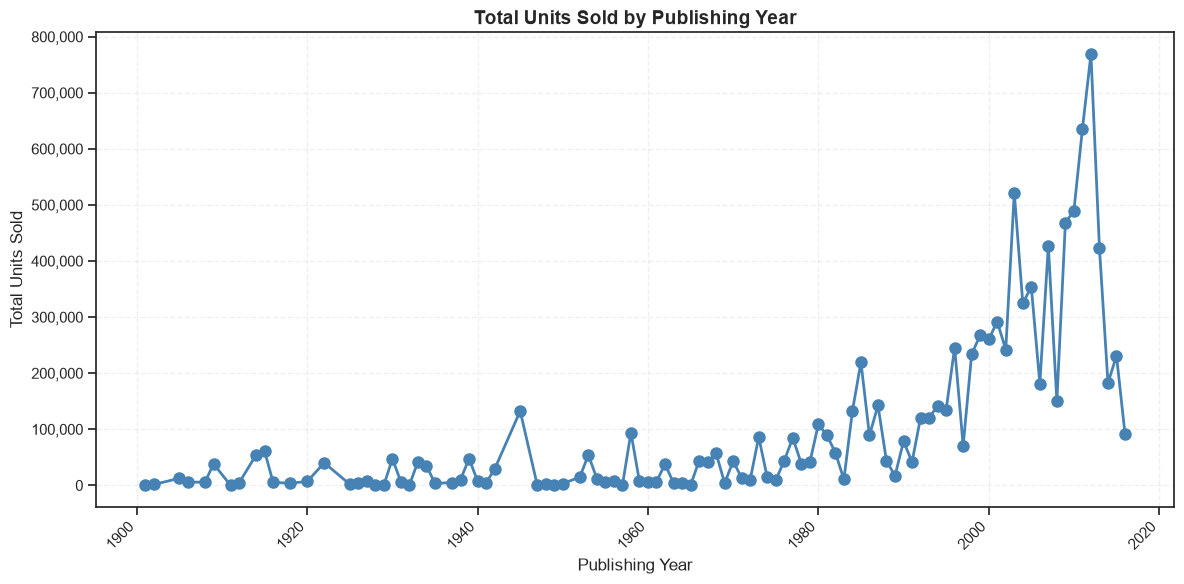

In [68]:
# Set style
sns.set_theme(style='ticks')

# Group and plot with marker
ax = df.groupby("Publishing Year")["units sold"].sum().plot(
    kind="line", 
    marker='o', 
    figsize=(12, 6),
    color='steelblue',
    linewidth=2,
    markersize=8
)

# Add labels and title
plt.title('Total Units Sold by Publishing Year', fontsize=14, fontweight='bold')
plt.xlabel('Publishing Year', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Show all years on x-axis
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [69]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher', 'units sold'],
      dtype='str')